In [9]:
import pandas as pd

files = [
    "../data/world_cup.csv",
    "../data/matches_1930_2022.csv",
    "../data/fifa_ranking_2022-10-06.csv",
    "../data/fifa_ranking_2026-06-08.csv",
    "../data/schedule_2026.csv"
]

for file in files:
    df = pd.read_csv(file)

    print("\n" + "="*50)
    print(file)
    print("="*50)

    print(df.columns.tolist())


../data/world_cup.csv
['Year', 'Host', 'Teams', 'Champion', 'Runner-Up', 'TopScorrer', 'Attendance', 'AttendanceAvg', 'Matches']

../data/matches_1930_2022.csv
['home_team', 'away_team', 'home_score', 'home_xg', 'home_penalty', 'away_score', 'away_xg', 'away_penalty', 'home_manager', 'home_captain', 'away_manager', 'away_captain', 'Attendance', 'Venue', 'Officials', 'Round', 'Date', 'Score', 'Referee', 'Notes', 'Host', 'Year', 'home_goal', 'away_goal', 'home_goal_long', 'away_goal_long', 'home_own_goal', 'away_own_goal', 'home_penalty_goal', 'away_penalty_goal', 'home_penalty_miss_long', 'away_penalty_miss_long', 'home_penalty_shootout_goal_long', 'away_penalty_shootout_goal_long', 'home_penalty_shootout_miss_long', 'away_penalty_shootout_miss_long', 'home_red_card', 'away_red_card', 'home_yellow_red_card', 'away_yellow_red_card', 'home_yellow_card_long', 'away_yellow_card_long', 'home_substitute_in_long', 'away_substitute_in_long']

../data/fifa_ranking_2022-10-06.csv
['team', 'team_

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

world_cup = pd.read_csv("../data/world_cup.csv")
matches = pd.read_csv("../data/matches_1930_2022.csv")
rank22 = pd.read_csv("../data/fifa_ranking_2022-10-06.csv")
rank26 = pd.read_csv("../data/fifa_ranking_2026-06-08.csv")
schedule = pd.read_csv("../data/schedule_2026.csv")

Champion
Brazil          5
Italy           4
Argentina       3
Germany         2
France          2
Uruguay         2
West Germany    2
Spain           1
England         1
Name: count, dtype: int64


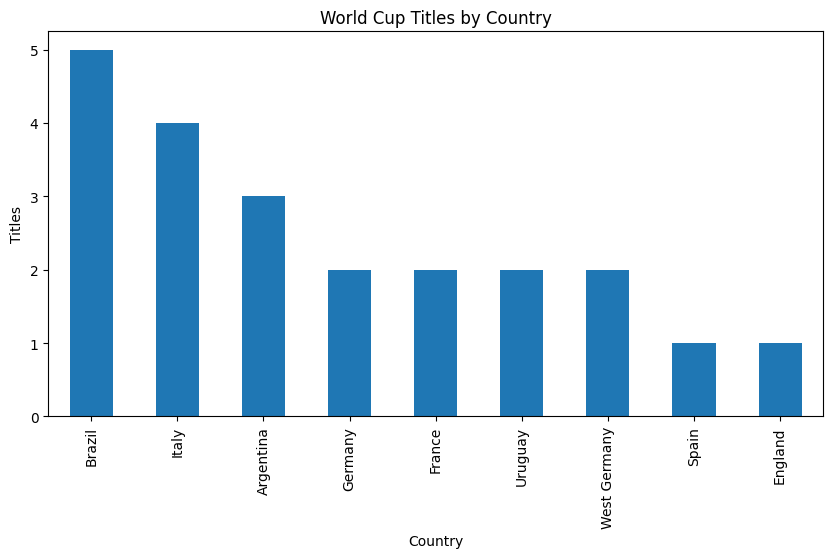

In [11]:
champions = world_cup["Champion"].value_counts()

print(champions)

champions.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("World Cup Titles by Country")
plt.xlabel("Country")
plt.ylabel("Titles")
plt.show()

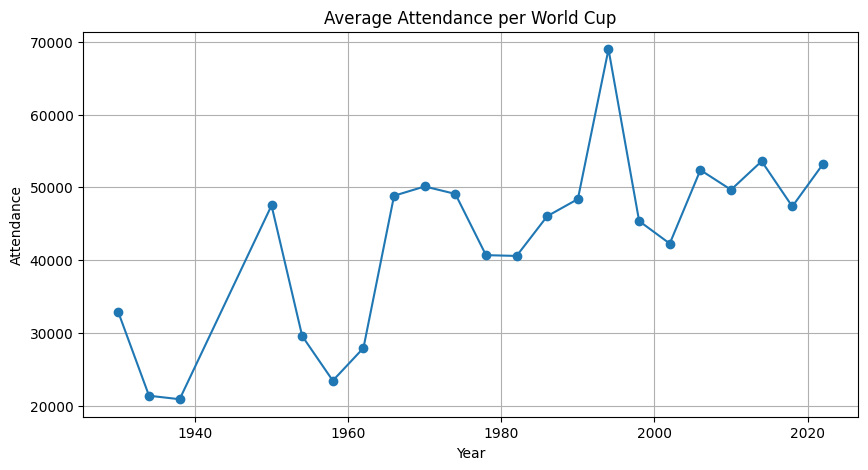

In [12]:
plt.figure(figsize=(10,5))

plt.plot(
    world_cup["Year"],
    world_cup["AttendanceAvg"],
    marker="o"
)

plt.title("Average Attendance per World Cup")
plt.xlabel("Year")
plt.ylabel("Attendance")
plt.grid()
plt.show()

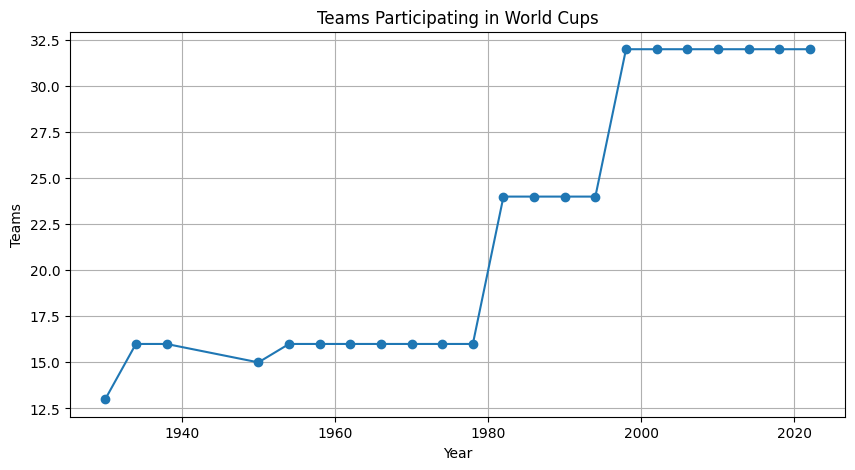

In [13]:
plt.figure(figsize=(10,5))

plt.plot(
    world_cup["Year"],
    world_cup["Teams"],
    marker="o"
)

plt.title("Teams Participating in World Cups")
plt.xlabel("Year")
plt.ylabel("Teams")
plt.grid()
plt.show()

In [14]:
home_goals = matches.groupby(
    "home_team"
)["home_score"].sum()

away_goals = matches.groupby(
    "away_team"
)["away_score"].sum()

total_goals = home_goals.add(
    away_goals,
    fill_value=0
)

top10 = total_goals.sort_values(
    ascending=False
).head(10)

print(top10)

Brazil          237.0
Argentina       152.0
France          136.0
Italy           128.0
Germany         126.0
Spain           108.0
West Germany    106.0
England         104.0
Netherlands      96.0
Uruguay          89.0
dtype: float64


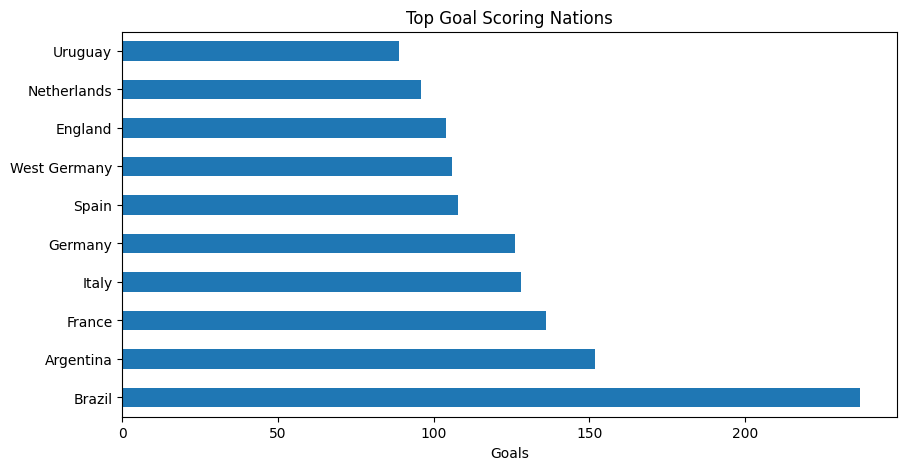

In [15]:
top10.plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Top Goal Scoring Nations")
plt.xlabel("Goals")
plt.show()

In [16]:
wins = {}

for _, row in matches.iterrows():

    if row["home_score"] > row["away_score"]:

        team = row["home_team"]

        wins[team] = wins.get(team,0) + 1

    elif row["away_score"] > row["home_score"]:

        team = row["away_team"]

        wins[team] = wins.get(team,0) + 1

wins = pd.Series(wins)

topwins = wins.sort_values(
    ascending=False
).head(10)

print(topwins)

Brazil          76
Argentina       47
Italy           45
France          39
Germany         37
England         32
West Germany    31
Spain           31
Netherlands     30
Uruguay         25
dtype: int64


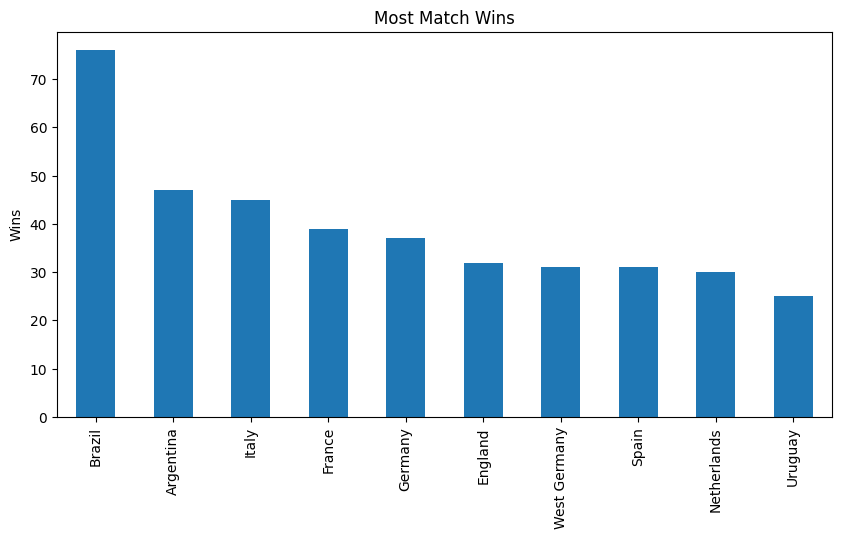

In [17]:
topwins.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Most Match Wins")
plt.ylabel("Wins")
plt.show()

In [18]:
all_goals = np.concatenate([
    matches["home_score"].values,
    matches["away_score"].values
])

print("Mean:", np.mean(all_goals))
print("Median:", np.median(all_goals))
print("Maximum:", np.max(all_goals))
print("Minimum:", np.min(all_goals))
print("Standard Deviation:", np.std(all_goals))

Mean: 1.4107883817427387
Median: 1.0
Maximum: 10
Minimum: 0
Standard Deviation: 1.4073487481026792


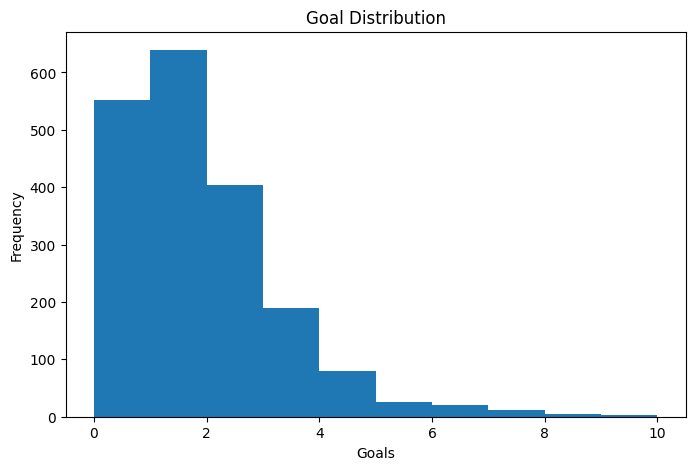

In [19]:
plt.figure(figsize=(8,5))

plt.hist(
    all_goals,
    bins=10
)

plt.title("Goal Distribution")
plt.xlabel("Goals")
plt.ylabel("Frequency")

plt.show()

In [20]:
comparison = pd.merge(
    rank22[["team","rank"]],
    rank26[["team","rank"]],
    on="team",
    suffixes=("_2022","_2026")
)

comparison["Improvement"] = (
    comparison["rank_2022"]
    - comparison["rank_2026"]
)

comparison = comparison.sort_values(
    "Improvement",
    ascending=False
)

print(comparison.head(10))

           team  rank_2022  rank_2026  Improvement
150   Indonesia        152        119           33
118      Angola        119         89           30
106      Kosovo        107         78           29
72     Congo DR         73         45           28
76   Uzbekistan         77         50           27
59       Panama         60         34           26
44      Türkiye         45         22           23
117   Guatemala        118         97           21
43      Ecuador         44         23           21
128     Comoros        129        108           21


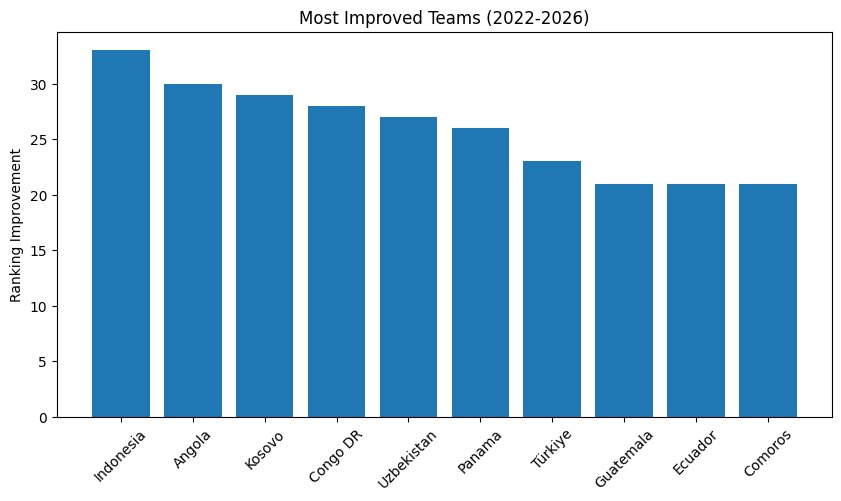

In [21]:
top_improved = comparison.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_improved["team"],
    top_improved["Improvement"]
)

plt.xticks(rotation=45)

plt.title("Most Improved Teams (2022-2026)")
plt.ylabel("Ranking Improvement")

plt.show()

In [22]:
top10_rank = rank26.sort_values(
    "rank"
).head(10)

print(
    top10_rank[
        ["team","rank","points"]
    ]
)

          team  rank       points
0    Argentina     1  1876.118331
1        Spain     2  1873.013187
2       France     3  1869.428449
3      England     4  1827.048678
4     Portugal     5  1766.177547
5       Brazil     6  1765.856297
6      Morocco     7  1755.100232
7  Netherlands     8  1751.097835
8      Belgium     9  1742.235945
9      Germany    10  1735.771984


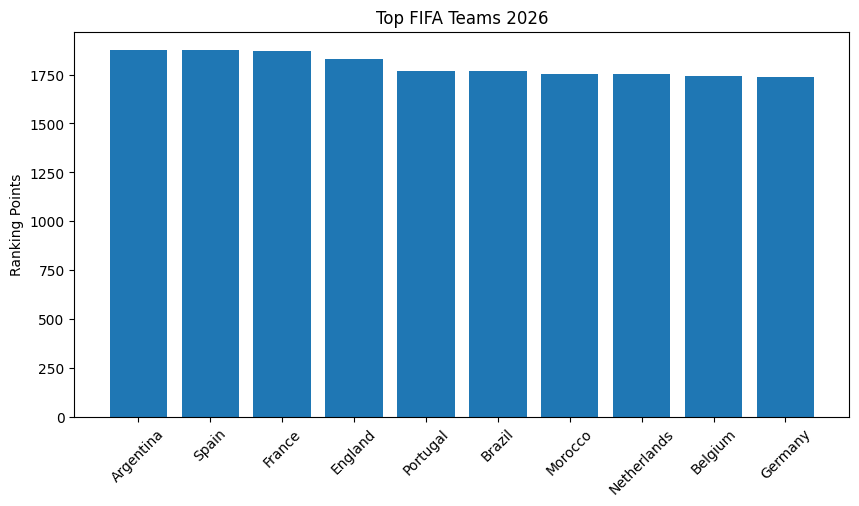

In [23]:
plt.figure(figsize=(10,5))

plt.bar(
    top10_rank["team"],
    top10_rank["points"]
)

plt.xticks(rotation=45)

plt.title("Top FIFA Teams 2026")
plt.ylabel("Ranking Points")

plt.show()

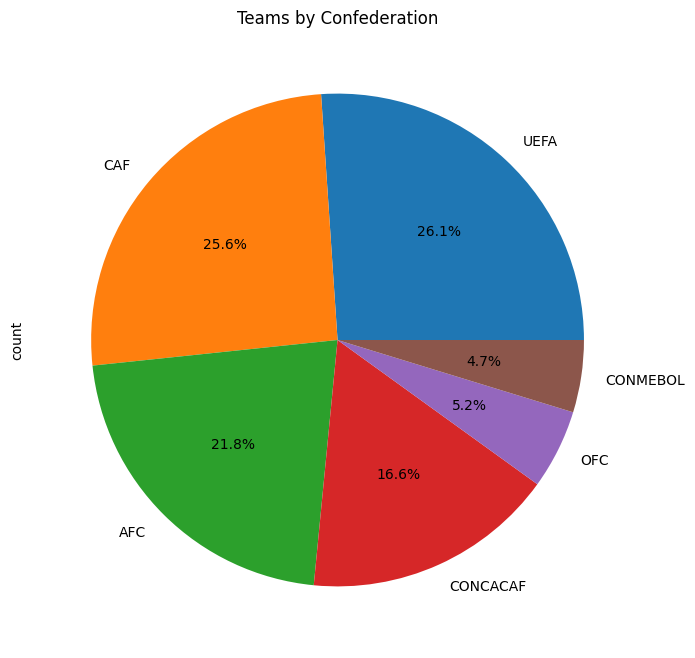

In [24]:
conf = rank26["association"].value_counts()

conf.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Teams by Confederation")
plt.show()


In [25]:
print(schedule.head())

print(
    schedule["Round"].value_counts()
)

         Round  Day        Date           Time  Score  Referee  Notes  Year  \
0  Group stage  Thu  2026-06-11  13:00 (22:00)    NaN      NaN    NaN  2026   
1  Group stage  Thu  2026-06-11  20:00 (05:00)    NaN      NaN    NaN  2026   
2  Group stage  Fri  2026-06-12  15:00 (22:00)    NaN      NaN    NaN  2026   
3  Group stage  Fri  2026-06-12  18:00 (04:00)    NaN      NaN    NaN  2026   
4  Group stage  Sat  2026-06-13  12:00 (22:00)    NaN      NaN    NaN  2026   

        home_team           away_team  
0          Mexico        South Africa  
1  Korea Republic             Czechia  
2          Canada  Bosnia-Herzegovina  
3   United States            Paraguay  
4           Qatar         Switzerland  
Round
Group stage    72
Name: count, dtype: int64


In [28]:
plt.savefig("../charts/world_cup_titles.png")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../charts/world_cup_titles.png'

<Figure size 640x480 with 0 Axes>